In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt


In [2]:
train_dir = r"C:\Users\varun\OneDrive\Documents\DQL\Deep Learning\CNN\Train data"
val_dir   = r"C:\Users\varun\OneDrive\Documents\DQL\Deep Learning\CNN\Val data"
test_dir  = r"C:\Users\varun\OneDrive\Documents\DQL\Deep Learning\CNN\Test data"

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 50 files belonging to 5 classes.
Found 10 files belonging to 5 classes.
Found 15 files belonging to 5 classes.


In [4]:
class_names = train_ds.class_names

print(class_names)

['APJ', 'Billgates', 'Elon', 'Varun', 'Vibhu']


In [5]:
print("Number of classes:", len(class_names))

Number of classes: 5


In [6]:
print("Train classes:", train_ds.class_names)
print("Validation classes:", val_ds.class_names)
print("Test classes:", test_ds.class_names)

Train classes: ['APJ', 'Billgates', 'Elon', 'Varun', 'Vibhu']
Validation classes: ['APJ', 'Billgates', 'Elon', 'Varun', 'Vibhu']
Test classes: ['APJ', 'Billgates', 'Elon', 'Varun', 'Vibhu']


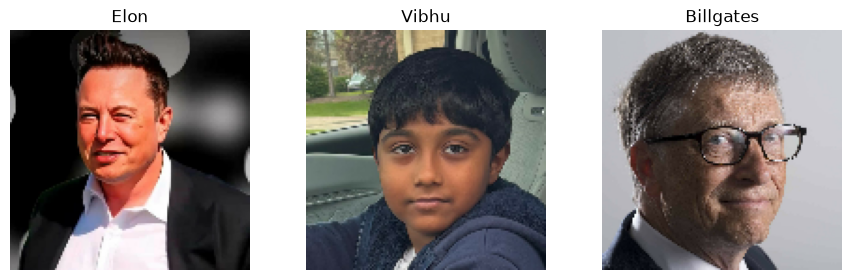

In [7]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(3):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (16, 128, 128, 3)
Labels shape: (16,)


In [9]:
normalization_layer = layers.Rescaling(1./255)

In [10]:
# already cropped all the pictures to the desired size and chkd manually
#data_augmentation = keras.Sequential([
#    layers.RandomFlip("horizontal"),
#    layers.RandomRotation(0.1),
#    layers.RandomZoom(0.1),
#], name="data_augmentation")

In [13]:
model = keras.Sequential([
    
    # Input
    layers.Input(shape=(128, 128, 3)),
    
      
    # Normalize pixels from 0-255 to 0-1
    layers.Rescaling(1./255),
    
    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    # Convert feature maps into a vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(128, activation="relu"),
    
    # Dropout to reduce overfitting
    layers.Dropout(0.5),
    
    # Output layer
    layers.Dense(5, activation="softmax")
])

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20


C:\Users\varun\anaconda3\envs\Tensor_flow\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - accuracy: 0.1800 - loss: 1.8589 - val_accuracy: 0.2000 - val_loss: 1.5815
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.3000 - loss: 1.5774 - val_accuracy: 0.4000 - val_loss: 1.5476
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.3600 - loss: 1.5493 - val_accuracy: 0.4000 - val_loss: 1.4975
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.5800 - loss: 1.3958 - val_accuracy: 0.3000 - val_loss: 1.3930
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - accuracy: 0.5000 - loss: 1.2283 - val_accuracy: 0.4000 - val_loss: 1.4039
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.6000 - loss: 1.0734 - val_accuracy: 0.4000 - val_loss: 1.3252
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - accuracy: 0.5200 - loss: 1.0325 - val_accuracy: 0.5000 - val_loss: 1.0861
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.7800 - loss: 0.7037 - val_accuracy: 0.5000 - val_loss: 1.3943
Epo

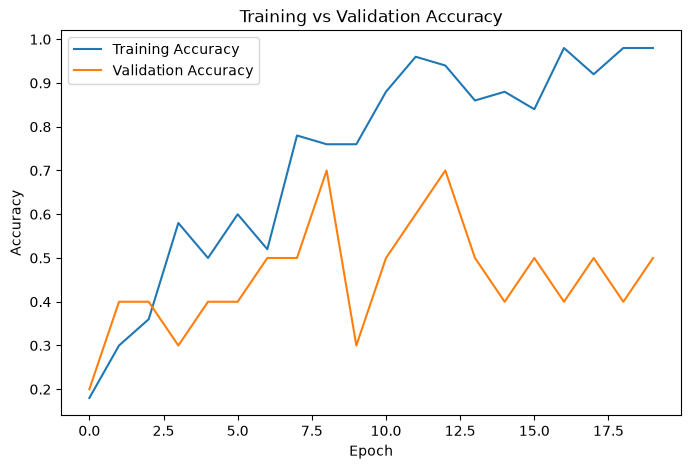

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

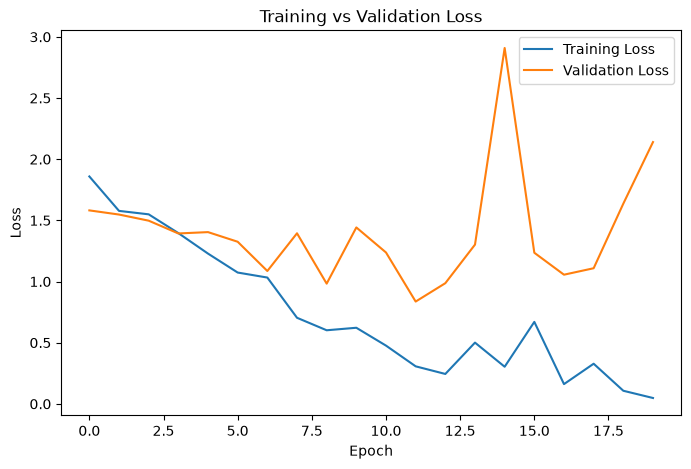

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.4667 - loss: 2.2669
Test Loss: 2.266935110092163
Test Accuracy: 0.46666666865348816


In [37]:
from tensorflow.keras.utils import load_img, img_to_array
image_path = r"C:\Users\varun\OneDrive\Documents\DQL\Deep Learning\CNN\Val data\Vibhu\vibhu_valid2.jpg"

image = load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = img_to_array(image)

image_array = np.expand_dims(image_array, axis=0)

In [38]:
prediction = model.predict(image_array)

predicted_class = np.argmax(prediction[0])

print("Predicted person:", class_names[predicted_class])
print("Confidence:", prediction[0][predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Predicted person: Vibhu
Confidence: 0.999798


In [39]:
model.save("person_classifier.h5")

In [40]:
from tensorflow.keras.models import load_model

loaded_model = load_model("person_classifier.h5")